In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors

from generate_colormap import *


from functools import partial
import starsim

In [2]:
pathdata = '/home/sophie-stucki/Documents/starsim_simulations/nina_spec/'
path_grid="/home/sophie-stucki/starsim/starsim/gif/"
conf_file_path = "/home/sophie-stucki/starsim/starsim/starsim_sun_mps.conf"

In [3]:
def simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path, dT_fc=None):
    """
    Iniialization of the starsim simulation for a particular set of parameters

    Params:
            -Q: facular_area_ratio
    Return:
            - ss: starsim object

    """
    
    #create the starsim object
    ss=starsim.StarSim(conf_file_path=conf_file_path)


    #set the Q parameter
    ss.active_region_types=type_list

    if dT_fc !=None:
        ss.facula_T_contrast = dT_fc

    #initialize the spot
    overlap=True

    #TODO: more modulable
    Nspots=len(spot_size_list)
    ss.spot_map=np.zeros([Nspots,8])
    for j in range(Nspots):
        ss.spot_map[j][0]=type_list[j]
        ss.spot_map[j][2]=200#lifetime spot
        ss.spot_map[j][1]=0#appearance time
        ss.spot_map[j][3]=latitude_list[j]#latitude (degrees) [0,180]
        ss.spot_map[j][4]=longitude_list[j]#longitude (degrees)	[0,360]
        ss.spot_map[j][5]=spot_size_list[j]#spot size (degrees)
    return ss

In [4]:
type_list = [0]
spot_size_list = [10]
latitude_list = [90]
longitude_list = [250]

period = 25
periods_nbr = 0.8
point_nbr = 5
bb_ratio = 1
t=np.linspace(0,period *periods_nbr,int(period *periods_nbr*point_nbr))

In [5]:
ss_mps = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_mps.phoenix_spectra = 0
ss_mps.convective_shift = 0
ss_mps.compute_forward(observables=['lc', 'rv'],t=t)

MPS-ATLAS spectra
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [100/100]%. [99/100]%]%ELSE
ELSE
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot: Add CFIST
Spot

In [6]:
ss_phoenix_blue = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_phoenix_blue.phoenix_spectra = 1
ss_phoenix_blue.convective_shift= 1
ss_phoenix_blue.compute_forward(observables=['lc', 'rv'],t=t)

PHOENIX spectra
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [100/100]%. [99/100]%]%RV shift
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [100/100]%. [99/100]%]%

In [7]:
ss_phoenix = simulation_init(type_list, spot_size_list, latitude_list, longitude_list, conf_file_path)
ss_phoenix.phoenix_spectra = 1
ss_phoenix.convective_shift= 0
ss_phoenix.compute_forward(observables=['lc', 'rv'],t=t)

PHOENIX spectra
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [100/100]%. [99/100]%]%RV shift
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Limb extrapolation: linear for mu <  0.1
Date 20.0. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [100/100]%. [99/100]%]%

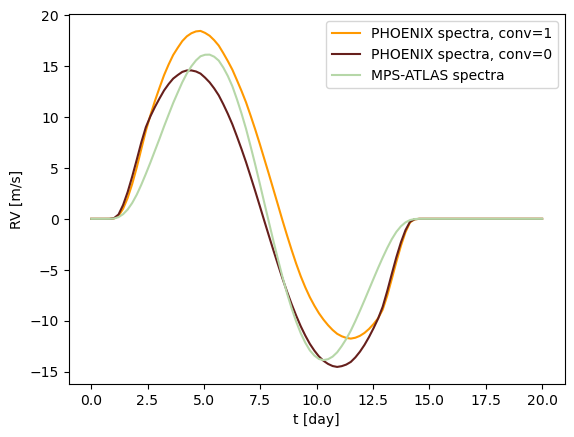

In [8]:
plt.plot(t,ss_phoenix_blue.results['rv'],color='#ff9900', label='PHOENIX spectra, conv=1') #raw phoenix erg/s/cm^2/cm
plt.plot(t,ss_phoenix.results['rv'],color='#661F1C', label='PHOENIX spectra, conv=0') #raw phoenix erg/s/cm^2/cm
plt.plot(t,ss_mps.results['rv'], color='#b6d7a8',label='MPS-ATLAS spectra') #raw mps erg * s^{-1} * cm^{-2} * Hz^{-1} * ster^{-1}

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('RV [m/s]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/rv_types_{}_bb_ratio_{}.png'.format(type_list, bb_ratio), dpi=300)
plt.show()